## Phase 4 - Feature Engineering

In this section, raw preprocessed text is transformed into structured numerical representations suitable for machine learning models. The goal is to construct features that capture both the **linguistic content** of the sentence and the **domain-specific interaction signals** identified during earlier analysis.

The feature engineering pipeline combines two complementary representations:

1. **TF-IDF Features**  
   Sparse vector representations derived from lemmatised text capture the importance of words and phrases (unigrams and bigrams). The vectoriser is trained only on the training set to prevent data leakage and ensure fair evaluation.

2. **Handcrafted Features**  
   A set of domain-informed features is engineered based on insights from EDA, including:
   - Drug entity positions and relative distance
   - Keyword-based interaction signals (mechanism, effect, advise, general)
   - Drug type encodings (brand, group, drug_n)
   - Data quality indicators (self-pairs, corpus source)
   - Semantic flags (negation, interaction terms, toxicity indicators)

These features are designed to explicitly encode patterns that may not be easily captured by purely statistical models.

Finally, both feature sets are combined into a single feature matrix, enabling models to leverage both **data-driven lexical patterns** and **expert-informed signals**.

## Setup and Imports

This section initialises the environment for feature engineering and modelling. It loads all required libraries for data handling, text vectorisation, and label encoding.

The configuration file is imported to ensure consistent access to project paths and parameters across notebooks. Core libraries such as NumPy and pandas are used for data manipulation, while scikit-learn components support feature extraction (TF-IDF) and label encoding.

Sparse matrix utilities are included to efficiently handle high-dimensional text features, which is critical for scalable NLP pipelines. Progress tracking and warning suppression are also configured to improve usability during execution.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../'))
from config import *

import os, re, pickle, warnings
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

## Data and Output Configuration

This section verifies the availability of preprocessed datasets and defines the inputs required for feature engineering.

The pipeline produces feature matrices, encoded labels, and supporting artefacts such as the TF-IDF vectoriser and label encoder, ensuring reproducibility and consistent transformations.

If inputs are missing, Phase 3 must be completed before proceeding.

In [2]:
for path in [TRAIN_PROCESSED, TEST_PROCESSED]:
    status = 'FOUND' if os.path.exists(path) else 'NOT FOUND'

## Data Loading and Schema Validation

This step loads the processed datasets from Phase 3 and validates that all required features are present before feature engineering begins.

A predefined list of required columns ensures that the dataset contains all necessary textual representations (e.g., cleaned text, lemmas), engineered features (keyword counts), and metadata (drug types, corpus source, labels). This prevents downstream errors caused by missing or incorrect inputs.

The validation step explicitly checks both training and test datasets, enforcing consistency across splits. If any required column is missing, execution is halted with a clear error message, ensuring that only correctly processed data is used.

This guarantees that the feature engineering pipeline operates on a complete and reliable dataset.

In [3]:
REQUIRED_COLS = [
    'lemmas', 'sentence_cleaned', 'sentence_masked',
    'keyword_count', 'kw_mechanism', 'kw_effect', 'kw_advise', 'kw_general',
    'is_self_pair', 'drug1_type', 'drug2_type', 'corpus_source',
    'interaction_type',
]

print('Loading data')
train_df = pd.read_csv(TRAIN_PROCESSED)
test_df = pd.read_csv(TEST_PROCESSED)

# Column validation
print('\nValidating required columns:')
for name, df in [('TRAIN', train_df), ('TEST', test_df)]:
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(
            f'{name} is missing columns: {missing}\n'
        )
    print(f'{name}: all {len(REQUIRED_COLS)} required columns present.')

print(f'\nTrain rows: {len(train_df):,}')
print(f'Test rows: {len(test_df):,}')
print(f'Train columns: {list(train_df.columns)}')

Loading data

Validating required columns:
TRAIN: all 13 required columns present.
TEST: all 13 required columns present.

Train rows: 27,792
Test rows: 6,657
Train columns: ['sentence_id', 'drug1_text', 'drug1_type', 'drug1_norm', 'drug2_text', 'drug2_type', 'drug2_norm', 'ddi', 'interaction_type', 'corpus_source', 'offset_valid', 'source_file', 'sentence_original', 'sentence_masked', 'sentence_cleaned', 'tokens', 'tokens_no_stop', 'lemmas', 'is_self_pair', 'keywords_found', 'keyword_count', 'kw_mechanism', 'kw_effect', 'kw_advise', 'kw_general']


## Self-Pair Filtering

This step optionally removes *self-pair* instances from the training dataset, where both drug mentions refer to the same textual entity.

Self-pairs can introduce noise, as they do not represent true interactions between distinct drugs. However, they may still be useful depending on the modelling objective, so filtering is controlled via a configuration flag (`FILTER_SELF_PAIRS`).

The implementation ensures robustness by converting the `is_self_pair` column to boolean, handling cases where values may be stored as strings (`'True'/'False'`). This prevents incorrect filtering behaviour.

The test dataset remains unchanged to preserve evaluation integrity. The final dataset sizes are reported to confirm the effect of filtering.

In [4]:
if FILTER_SELF_PAIRS and 'is_self_pair' in train_df.columns:
    before = len(train_df)

    train_df = train_df[
        ~train_df['is_self_pair'].astype(bool)
    ].reset_index(drop=True)

    print(f'Self-pair filter applied: {before:,} becomes {len(train_df):,} rows ({before-len(train_df)} removed)')

else:
    self_count = train_df['is_self_pair'].sum() if 'is_self_pair' in train_df.columns else 'unknown'
    print(f'Self-pair filter OFF. {self_count} self-pairs retained in training data.')

print(f'\nFinal training set: {len(train_df):,} rows')
print(f'Test set (unchanged): {len(test_df):,} rows')

Self-pair filter applied: 27,792 becomes 25,802 rows (1990 removed)

Final training set: 25,802 rows
Test set (unchanged): 6,657 rows


## TF-IDF Feature Extraction

This step converts textual data into numerical representations using Term Frequency–Inverse Document Frequency (TF-IDF), a standard technique for capturing the importance of words in a corpus.

The vectoriser is **fitted only on the training data** to prevent data leakage, ensuring that no information from the test set influences feature construction. The learned vocabulary is then applied to both training and test datasets.

Several design choices improve representation quality:
- **Sublinear term frequency scaling** reduces the dominance of very frequent words.
- **Unigrams and bigrams** capture both individual terms and short contextual phrases.
- **Minimum document frequency filtering** removes rare noise terms.
- **Custom token pattern** preserves hyphenated biomedical terms (e.g., *beta-blocker*).

The resulting feature matrices are high-dimensional and sparse, making them suitable for efficient storage and scalable model training.

A sample inspection of top TF-IDF terms provides interpretability and helps validate that meaningful features are being captured.

In [5]:
print('Building TF-IDF features')
print('Fitting vectoriser on TRAINING data only (prevents data leakage)')

vectoriser = TfidfVectorizer(
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=2,
    token_pattern=r'(?u)\b\w[\w\-]+\b',
)

train_tfidf = vectoriser.fit_transform(train_df['lemmas'].fillna(''))
test_tfidf = vectoriser.transform(test_df['lemmas'].fillna(''))

print(f'Train TF-IDF shape: {train_tfidf.shape}')
print(f'Test TF-IDF shape: {test_tfidf.shape}')
print(f'Vocabulary size: {len(vectoriser.vocabulary_):,}')
print(f'Matrix sparsity: {1 - train_tfidf.nnz / (train_tfidf.shape[0]*train_tfidf.shape[1]):.3%}')

print('\nTop 10 TF-IDF terms for first training row:')

feature_names = vectoriser.get_feature_names_out()
row0 = train_tfidf[0].toarray()[0]
top_idx = row0.argsort()[-10:][::-1]

for idx in top_idx:
    if row0[idx] > 0:
        print(f'{feature_names[idx]:<30} {row0[idx]:.4f}')

Building TF-IDF features
Fitting vectoriser on TRAINING data only (prevents data leakage)
Train TF-IDF shape: (25802, 5000)
Test TF-IDF shape: (6657, 5000)
Vocabulary size: 5,000
Matrix sparsity: 99.047%

Top 10 TF-IDF terms for first training row:
measure                        0.3273
laboratory test                0.3158
laboratory                     0.3088
total                          0.3054
week                           0.2975
29                             0.2889
drug2 concentration            0.2777
prior                          0.2666
monitor                        0.2619
test                           0.2467


## Positional Feature Engineering

This step extracts structural features based on the relative positions of drug entities within each sentence. These features capture syntactic relationships that are often indicative of interaction patterns.

Two key features are computed:

- **Normalised Positions**: The relative locations of `DRUG1` and `DRUG2` within the sentence, scaled between 0 and 1. This provides a position-invariant representation of where interactions occur.
- **Distance Between Drugs**: The number of words between the two drug mentions, capturing how closely they are referenced in context.

These features were corrected from earlier implementations to align with the actual output of Phase 3 preprocessing, where drug tokens appear as lowercase `drug1` and `drug2`. 

Such positional signals are lightweight yet informative, and can improve performance in classical models by encoding interaction structure beyond raw text.

In [6]:
def get_drug_positions(sentence_cleaned: str):
    words = sentence_cleaned.split()
    total = len(words) if words else 1
    pos1, pos2 = 0.5, 0.5

    for i, word in enumerate(words):
        if word == 'drug1':
            pos1 = i / total
        if word == 'drug2':
            pos2 = i / total

    return pos1, pos2


def get_words_between_drugs(sentence_cleaned: str) -> int:
    pattern = re.search(
        r'\bdrug1\b(.*?)\bdrug2\b|\bdrug2\b(.*?)\bdrug1\b',
        sentence_cleaned
    )
    if pattern:
        between = pattern.group(1) or pattern.group(2) or ''
        return len(between.split())
    return -1


# Verification
print('Drug position function tests:')

sample = 'laboratory tests response to drug1 should be monitored by measuring drug2 concentrations'

p1, p2 = get_drug_positions(sample)
dist = get_words_between_drugs(sample)

print(f'Sentence: "{sample[:70]}..."')
print(f'DRUG1 position: {p1:.3f}')
print(f'DRUG2 position: {p2:.3f}')
print(f'Words between: {dist}')

assert p1 != 0.5 or p2 != 0.5
assert dist != -1

Drug position function tests:
Sentence: "laboratory tests response to drug1 should be monitored by measuring dr..."
DRUG1 position: 0.333
DRUG2 position: 0.833
Words between: 5


## Handcrafted Feature Engineering

This step constructs a set of interpretable, domain-informed features that complement TF-IDF representations. These features encode structural, semantic, and metadata signals that are not fully captured by text-based embeddings.

A total of **24 handcrafted features** are extracted for each drug pair, grouped into five categories:

- **Position Features**: Capture the relative locations and distance between drug mentions.
- **Keyword Counts**: Quantify the presence of interaction-specific terms identified during EDA.
- **Entity Type Encoding**: Represent drug types (e.g., brand, group) based on observed interaction patterns.
- **Data Quality and Source Features**: Include indicators such as self-pairs and corpus origin (DrugBank vs MedLine).
- **Keyword Presence Flags**: Binary indicators for clinically meaningful signals such as negation, contraindications, and toxicity.

These features are computationally efficient and highly interpretable, making them particularly valuable for classical machine learning models. They also provide complementary signals that can enhance hybrid modelling approaches when combined with TF-IDF or transformer embeddings.

The use of `itertuples()` ensures efficient processing of large datasets, significantly improving runtime performance.

In [7]:
DRUG_TYPES = ['brand', 'group', 'drug_n']

def extract_handcrafted_features(df: pd.DataFrame) -> np.ndarray:
    NEGATION = {'not', 'no', 'without', 'neither', 'nor', 'never', 'none'}
    INTERACT = {'interact', 'interaction'}
    CONTRA = {'contraindicated'}
    MONITOR = {'monitor', 'caution', 'avoid'}
    DANGER = {'toxicity', 'bleeding', 'adverse'}

    rows = []

    for row in tqdm(df.itertuples(index=False), total=len(df), desc='Handcrafted features'):
        cleaned = str(getattr(row, 'sentence_cleaned', '')).lower()
        words_set = set(cleaned.split())

        # A: position
        pos1, pos2 = get_drug_positions(cleaned)
        distance = abs(pos1 - pos2)
        words_between = get_words_between_drugs(cleaned)

        # B: keyword counts
        kw_total = int(getattr(row, 'keyword_count', 0))
        kw_mech = int(getattr(row, 'kw_mechanism', 0))
        kw_eff = int(getattr(row, 'kw_effect', 0))
        kw_adv = int(getattr(row, 'kw_advise', 0))
        kw_gen = int(getattr(row, 'kw_general', 0))

        # C: entity types
        d1_type = str(getattr(row, 'drug1_type', 'drug')).lower()
        d2_type = str(getattr(row, 'drug2_type', 'drug')).lower()

        d1_brand = int(d1_type == 'brand')
        d1_group = int(d1_type == 'group')
        d1_drug_n = int(d1_type == 'drug_n')

        d2_brand = int(d2_type == 'brand')
        d2_group = int(d2_type == 'group')
        d2_drug_n = int(d2_type == 'drug_n')

        same_type = int(d1_type == d2_type)

        # D: quality & corpus
        is_self = int(bool(getattr(row, 'is_self_pair', False)))
        is_dbank = int(str(getattr(row, 'corpus_source', '')).lower() == 'drugbank')
        sent_len = len(cleaned.split())

        # E: keyword flags
        has_neg = int(bool(words_set & NEGATION))
        has_interact = int(bool(words_set & INTERACT))
        has_contra = int(bool(words_set & CONTRA))
        has_monitor = int(bool(words_set & MONITOR))
        has_danger = int(bool(words_set & DANGER))

        rows.append([
            pos1, pos2, distance, words_between,
            kw_total, kw_mech, kw_eff, kw_adv, kw_gen,
            d1_brand, d1_group, d1_drug_n,
            d2_brand, d2_group, d2_drug_n,
            same_type,
            is_self, is_dbank, sent_len,
            has_neg, has_interact, has_contra, has_monitor, has_danger,
        ])

    return np.array(rows, dtype=np.float32)


FEATURE_NAMES = [
    'drug1_position', 'drug2_position', 'position_distance', 'words_between',
    'kw_total', 'kw_mechanism', 'kw_effect', 'kw_advise', 'kw_general',
    'drug1_is_brand', 'drug1_is_group', 'drug1_is_drug_n',
    'drug2_is_brand', 'drug2_is_group', 'drug2_is_drug_n',
    'same_entity_type',
    'is_self_pair', 'is_drugbank', 'sentence_length',
    'has_negation', 'has_interact', 'has_contraindicated', 'has_monitor', 'has_danger',
]

print(f'Handcrafted feature count: {len(FEATURE_NAMES)}')

Handcrafted feature count: 24


## Handcrafted Feature Extraction and Inspection

This step generates handcrafted feature matrices for training and test data, capturing positional, semantic, and metadata signals.

Summary statistics are computed to verify feature quality, distribution, and consistency.

This ensures the features are correctly computed before integration with other representations.

In [8]:
print('Extracting handcrafted features')

train_hc = extract_handcrafted_features(train_df)
test_hc = extract_handcrafted_features(test_df)

print(f'\nTrain handcrafted shape: {train_hc.shape}')
print(f'Test handcrafted shape: {test_hc.shape}')

hc_df = pd.DataFrame(train_hc, columns=FEATURE_NAMES)

print('\nHandcrafted feature statistics (training set):')
print(hc_df.describe().round(3).to_string())

Extracting handcrafted features


Handcrafted features: 100%|██████████| 6657/6657 [00:00<00:00, 65986.08it/s]


Train handcrafted shape: (25802, 24)
Test handcrafted shape: (6657, 24)

Handcrafted feature statistics (training set):
       drug1_position  drug2_position  position_distance  words_between   kw_total  kw_mechanism  kw_effect  kw_advise  kw_general  drug1_is_brand  drug1_is_group  drug1_is_drug_n  drug2_is_brand  drug2_is_group  drug2_is_drug_n  same_entity_type  is_self_pair  is_drugbank  sentence_length  has_negation  has_interact  has_contraindicated  has_monitor  has_danger
count       25802.000       25802.000          25802.000      25802.000  25802.000     25802.000  25802.000  25802.000   25802.000       25802.000       25802.000        25802.000       25802.000       25802.000        25802.000         25802.000       25802.0    25802.000        25802.000     25802.000     25802.000            25802.000    25802.000   25802.000
mean            0.413           0.677              0.301          9.587      2.246         0.935      0.146      0.237       0.927           0.102   

## Feature Discriminative Analysis

This step evaluates the effectiveness of handcrafted features by analysing their average values across interaction classes.

By grouping features by `interaction_type`, we can observe whether certain features are more prominent in specific classes. A feature is considered *discriminative* if it shows clear variation between classes, particularly between the majority class (*false*) and true interaction classes.

Key checks include:
- **Negation patterns**: Expected to be higher in the *false* class, as non-interactions often involve negated statements.
- **Keyword features**: Mechanism, effect, and advisory keywords should align with their respective interaction types.
- **Entity types**: Certain combinations (e.g., brand/group) may correlate with higher interaction likelihood.
- **Positional features**: Differences in drug proximity may reflect interaction structure.

This validation step ensures that the engineered features capture meaningful patterns consistent with earlier EDA findings, reinforcing their usefulness for downstream models.

In [9]:
hc_df['interaction_type'] = train_df['interaction_type'].values

LABEL_ORDER = ['false', 'effect', 'mechanism', 'advise', 'int']

check_features = [
    'has_negation', 'kw_mechanism', 'kw_effect', 'kw_advise',
    'drug1_is_brand', 'drug1_is_group', 'is_self_pair', 'position_distance'
]

print('Mean feature value by interaction type:')
print('(higher values in non-false classes = feature is discriminative)\n')

pivot = (
    hc_df
    .groupby('interaction_type')[check_features]
    .mean()
    .reindex(LABEL_ORDER)
)

print(pivot.round(3).to_string())

print('\nValidation:')

neg_false = pivot.loc['false', 'has_negation']
neg_effect = pivot.loc['effect', 'has_negation']

print(f'has_negation — false: {neg_false:.3f}  effect: {neg_effect:.3f}')

if neg_false > neg_effect:
    print('Negation is higher in false class (matches EDA finding)')
else:
    print('Negation pattern unexpected')

Mean feature value by interaction type:
(higher values in non-false classes = feature is discriminative)

                  has_negation  kw_mechanism  kw_effect  kw_advise  drug1_is_brand  drug1_is_group  is_self_pair  position_distance
interaction_type                                                                                                                   
false                    0.195         0.961      0.129      0.214           0.090           0.273           0.0              0.274
effect                   0.072         0.267      0.401      0.257           0.132           0.368           0.0              0.443
mechanism                0.075         1.724      0.116      0.210           0.156           0.132           0.0              0.477
advise                   0.312         0.481      0.142      0.857           0.283           0.174           0.0              0.419
int                      0.032         0.407      0.063      0.169           0.037           0.106    

## Feature Combination

This step combines textual and handcrafted features into a single unified representation for model training.

The TF-IDF matrix captures high-dimensional lexical patterns, while the handcrafted features provide structured, interpretable signals such as positional relationships, keyword presence, and entity types. Combining both allows the model to leverage complementary information sources.

Since TF-IDF features are stored in a sparse format, the handcrafted feature matrix is converted to a sparse representation before concatenation. This ensures memory efficiency and compatibility with downstream machine learning algorithms.

The final feature matrix significantly increases the representational capacity of the model, enabling it to learn both semantic and structural patterns in drug–drug interactions.

In [10]:
print("Building feature set using TF-IDF and handcrafted features")

def combine_features(tfidf_matrix, handcrafted_matrix):
    hc_sparse = sparse.csr_matrix(handcrafted_matrix)
    return sparse.hstack([tfidf_matrix, hc_sparse], format='csr')

X_train = combine_features(train_tfidf, train_hc)
X_test  = combine_features(test_tfidf,  test_hc)

print(f'Final X_train shape : {X_train.shape}')
print(f'Final X_test shape : {X_test.shape}')
print(f'TF-IDF features : {train_tfidf.shape[1]}')
print(f'Handcrafted features: {train_hc.shape[1]}')
print(f'Total features : {X_train.shape[1]}')
print(f'Matrix density : {X_train.nnz / (X_train.shape[0]*X_train.shape[1]):.4%}')

Building feature set using TF-IDF and handcrafted features
Final X_train shape : (25802, 5024)
Final X_test shape : (6657, 5024)
TF-IDF features : 5000
Handcrafted features: 24
Total features : 5024
Matrix density : 1.1431%


## Label Encoding

This step converts categorical interaction labels into numerical form required for machine learning models.

A `LabelEncoder` is used to map each interaction type to an integer. The encoding is deterministic and follows alphabetical ordering of class names, ensuring consistency across training and test sets.

The encoder is fitted on the training data and then applied to the test data to prevent any leakage of label information. The resulting encoded labels (`y_train`, `y_test`) serve as target variables for model training and evaluation.

Class distribution is also inspected after encoding to confirm alignment with earlier observations of dataset imbalance. This reinforces the need for appropriate evaluation metrics and class weighting in subsequent modelling steps.

In [11]:
print('Encoding labels')

encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df['interaction_type'])
y_test  = encoder.transform(test_df['interaction_type'])

print(f'Classes : {list(encoder.classes_)}')
print(f'Mapping : { {c: int(i) for i, c in enumerate(encoder.classes_)} }')
print(f'y_train shape: {y_train.shape}')
print(f'y_test  shape: {y_test.shape}')

print('\nClass counts in training labels:')

from collections import Counter

counts = Counter(y_train)

for cls_int, count in sorted(counts.items()):
    cls_name = encoder.classes_[cls_int]
    print(f'{cls_int} ({cls_name}) : {count:,}')

Encoding labels
Classes : ['advise', 'effect', 'false', 'int', 'mechanism']
Mapping : {'advise': 0, 'effect': 1, 'false': 2, 'int': 3, 'mechanism': 4}
y_train shape: (25802,)
y_test  shape: (6657,)

Class counts in training labels:
0 (advise) : 826
1 (effect) : 1,685
2 (false) : 21,787
3 (int) : 189
4 (mechanism) : 1,315


## Saving Feature Matrices and Artefacts

This step persists all processed features and fitted artefacts required for downstream modelling and evaluation.

Sparse feature matrices for training and testing are stored in compressed format to optimise memory usage. Corresponding label arrays are saved separately for efficient loading during model training.

Additionally, the fitted TF-IDF vectoriser and label encoder are serialised to ensure reproducibility and consistency across different stages of the pipeline. A combined list of feature names, including both textual and engineered features, is also stored for interpretability and future analysis.

In [12]:
# Feature matrices
sparse.save_npz(TRAIN_FEATURES_NPZ, X_train)
sparse.save_npz(TEST_FEATURES_NPZ,  X_test)

np.save(Y_TRAIN_NPY, y_train)
np.save(Y_TEST_NPY,  y_test)

# Fitted artefacts
with open(TFIDF_VECTORISER_PKL, 'wb') as f:
    pickle.dump(vectoriser, f)

with open(LABEL_ENCODER_PKL, 'wb') as f:
    pickle.dump(encoder, f)

all_feature_names = list(vectoriser.get_feature_names_out()) + FEATURE_NAMES

with open(FEATURE_NAMES_PKL, 'wb') as f:
    pickle.dump(all_feature_names, f)

## Visualisation Setup

This section prepares the environment for feature visualisation by ensuring required data structures and configurations are available.

If needed, the handcrafted feature DataFrame is reconstructed and labels are attached for class-wise analysis.

Default settings for label order, colours, and class names are initialised to ensure consistent and reproducible plots.

In [13]:
# Reuse handcrafted feature dataframe if available
if 'hc_df' not in globals():
    hc_df = pd.DataFrame(train_hc, columns=FEATURE_NAMES)

if 'interaction_type' not in hc_df.columns:
    hc_df['interaction_type'] = train_df['interaction_type'].values

if 'LABEL_ORDER' not in globals():
    LABEL_ORDER = ['false', 'effect', 'mechanism', 'advise', 'int']

if 'LABEL_COLOURS' not in globals():
    LABEL_COLOURS = {
        'false': '#7F7F7F',
        'effect': '#F28E2B',
        'mechanism': '#4E79A7',
        'advise': '#E15759',
        'int': '#76B7B2',
    }

if 'CLASS_NAMES' not in globals():
    CLASS_NAMES = list(encoder.classes_)

## Feature Correlation Analysis

This step analyses relationships between handcrafted features using a Pearson correlation matrix to identify redundancy and dependencies.

Highly correlated feature pairs are highlighted to detect potential multicollinearity and guide feature selection.

Low overall correlation indicates that features contribute complementary information, supporting effective model performance.

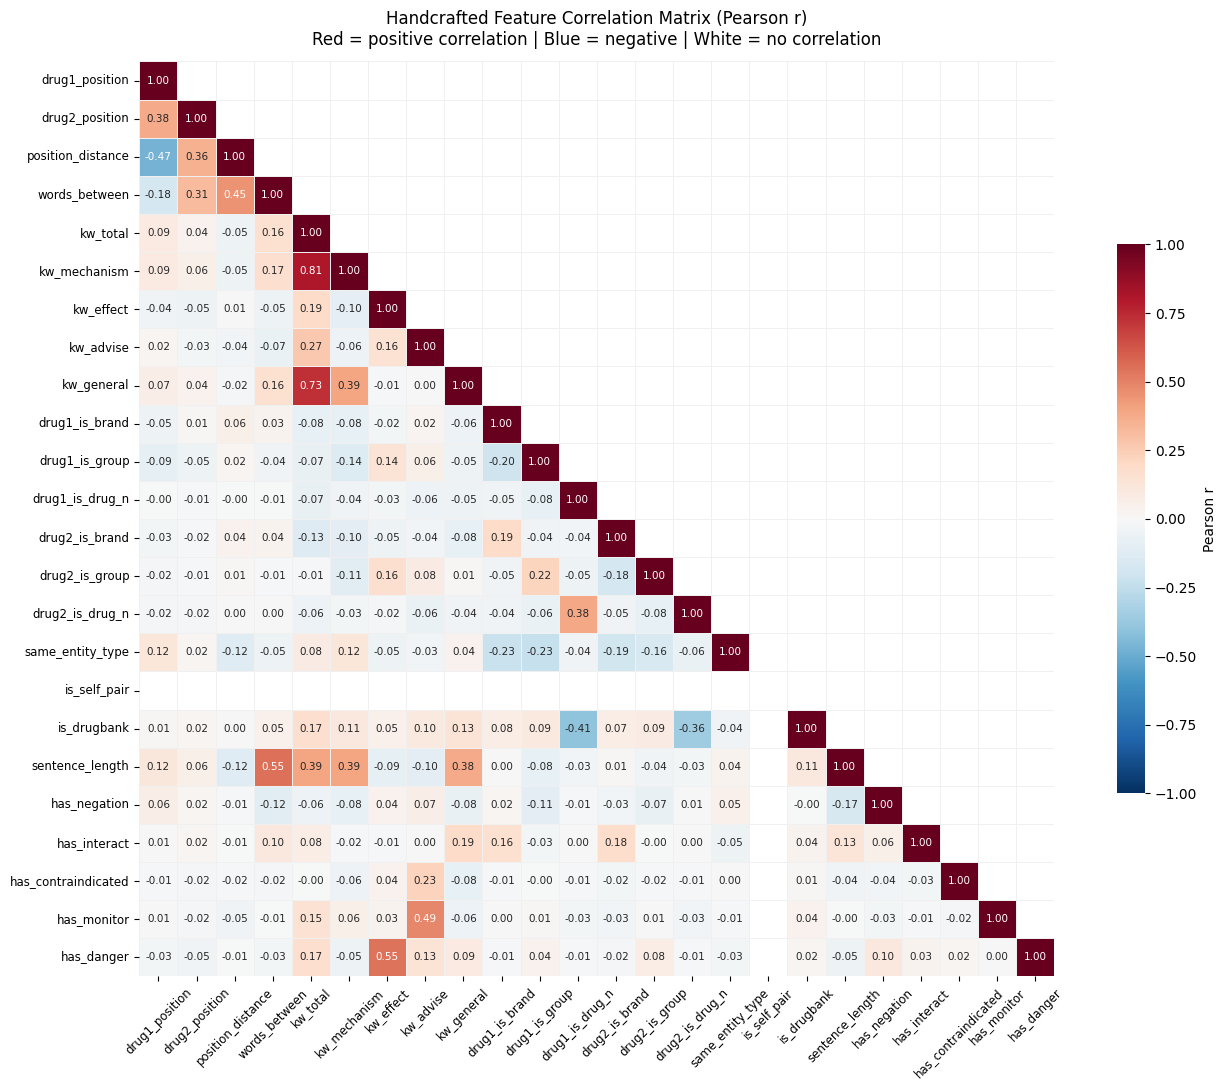

High-correlation pairs (|r| > 0.5):
kw_mechanism × kw_total  r=0.811
kw_general × kw_total  r=0.73
sentence_length × words_between  r=0.552
has_danger × kw_effect  r=0.545


In [14]:
feature_names_hc_safe = [f for f in FEATURE_NAMES if f in hc_df.columns]

corr_matrix = hc_df[feature_names_hc_safe].corr(method='pearson')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    linecolor='#F0F0F0',
    annot_kws={'size': 7.5},
    cbar_kws={'label': 'Pearson r', 'shrink': 0.6},
    square=True,
)

ax.set_title(
    'Handcrafted Feature Correlation Matrix (Pearson r)\n'
    'Red = positive correlation | Blue = negative | White = no correlation',
    fontsize=12,
    pad=12
)

ax.tick_params(axis='x', labelsize=8.5, rotation=45)
ax.tick_params(axis='y', labelsize=8.5, rotation=0)

plt.tight_layout()
plt.show()

high_corr = []

for i, f1 in enumerate(feature_names_hc_safe):
    for j, f2 in enumerate(feature_names_hc_safe):
        if j >= i:
            continue
        r = corr_matrix.loc[f1, f2]
        if abs(r) > 0.5:
            high_corr.append((f1, f2, round(r, 3)))

print('High-correlation pairs (|r| > 0.5):')

if high_corr:
    for f1, f2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'{f1} × {f2}  r={r}')
else:
    print('None — features are largely independent.')

## Keyword Feature Distribution Analysis

This visualisation examines how keyword-based features are distributed across different interaction classes using density plots.

Each subplot represents a keyword group (e.g., *mechanism*, *effect*, *advise*, *general*), showing how frequently these keywords appear in sentences belonging to each class. Kernel density estimation (KDE) is used to smooth the distributions, making patterns easier to interpret.

Small random noise (jitter) is added to avoid overplotting and improve visual clarity. The mean value for each class is displayed in the legend for quick comparison.

Well-separated density curves indicate that a keyword feature is highly discriminative for certain interaction types. For example, mechanism-related keywords should show higher density in the *mechanism* class.

This analysis validates that keyword features align with their intended semantic roles and contribute meaningful signals for classification.

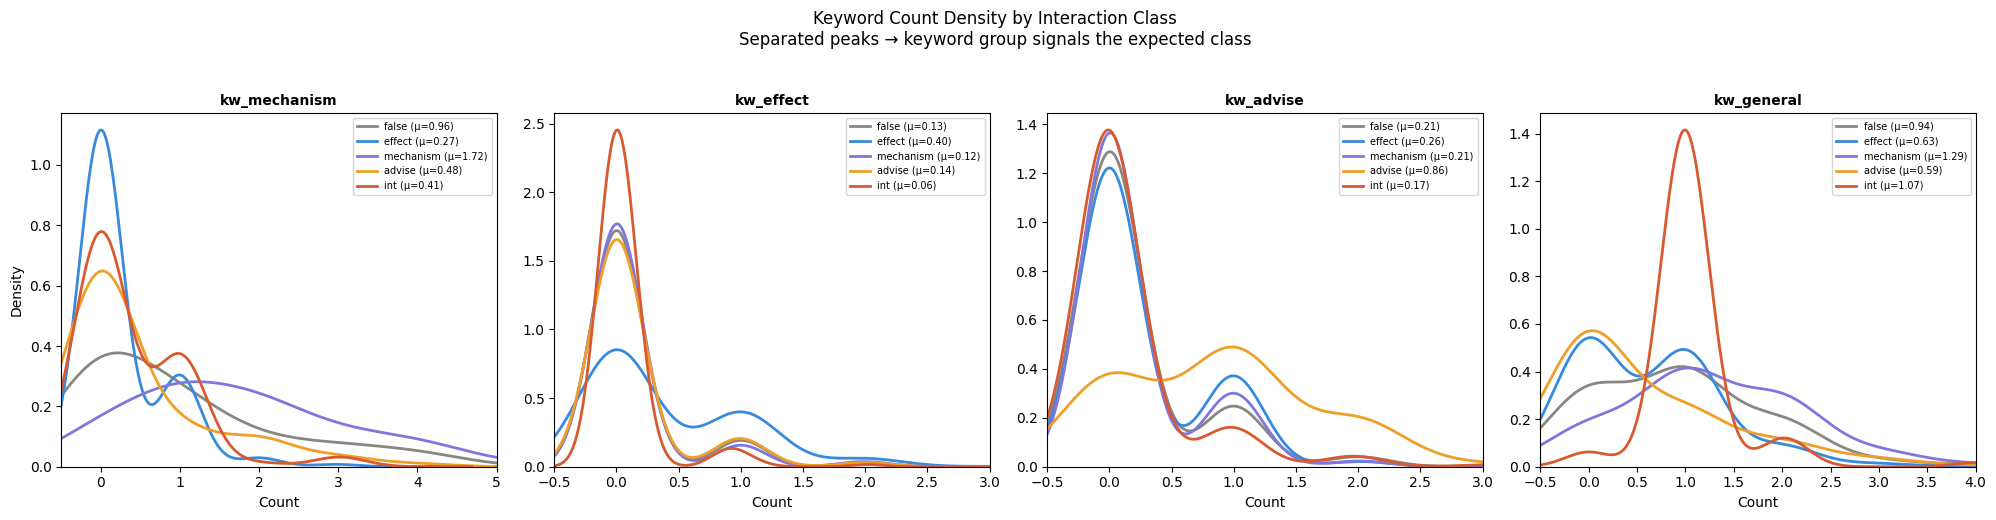

In [15]:
kw_features = ['kw_mechanism', 'kw_effect', 'kw_advise', 'kw_general']
kw_features = [f for f in kw_features if f in hc_df.columns]

if kw_features:
    fig, axes = plt.subplots(1, len(kw_features), figsize=(20, 5))

    if len(kw_features) == 1:
        axes = [axes]

    np.random.seed(42)

    for ax, feat in zip(axes, kw_features):
        for label in LABEL_ORDER:
            data = hc_df[hc_df['interaction_type'] == label][feat].dropna()

            if len(data) > 1:
                data_jittered = (
                    data + np.random.normal(0, 0.08, len(data))
                ).clip(lower=-0.1)

                data_jittered.plot.kde(
                    ax=ax,
                    label=f'{label} (μ={data.mean():.2f})',
                    color=LABEL_COLOURS[label],
                    linewidth=2.0,
                    bw_method=0.5,
                )

        upper = min(hc_df[feat].quantile(0.99) + 1, 8)

        ax.set_xlim(-0.5, upper)
        ax.set_title(feat, fontsize=10, fontweight='bold', pad=6)
        ax.set_xlabel('Count')
        ax.set_ylabel('Density' if ax is axes[0] else '')
        ax.legend(fontsize=7, loc='upper right')
        ax.set_ylim(bottom=0)

    plt.suptitle(
        'Keyword Count Density by Interaction Class\n'
        'Separated peaks → keyword group signals the expected class',
        fontsize=12,
        y=1.03
    )

    plt.tight_layout()
    plt.show()

else:
    print('\nSkipping keyword density plot because keyword columns not found.')

## Feature Engineering Summary

In this phase, raw text is transformed into a structured feature representation using a hybrid approach that combines TF-IDF features with domain-specific handcrafted features.

TF-IDF captures lexical and contextual patterns, while handcrafted features encode positional, semantic, and biomedical signals such as keyword presence, entity types, and negation cues.

All features are integrated into a unified sparse matrix, with consistent label encoding and saved artefacts to ensure reproducibility and seamless use in downstream modelling.

In [16]:
print('-' * 28)
print('FEATURE SUMMARY')
print('-' * 28)
print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples : {X_test.shape[0]:,}')
print(f'Total features per sample : {X_train.shape[1]:,}')
print(f'TF-IDF features : {train_tfidf.shape[1]:,}')
print(f'Handcrafted features : {train_hc.shape[1]:,}')
print(f'Label mapping : { {c: int(i) for i, c in enumerate(encoder.classes_)} }')
print()
print('Handcrafted feature groups:')
groups = [
    ('A — Drug position  ', 'drug1_position, drug2_position, position_distance, words_between'),
    ('B — Keyword counts ', 'kw_total, kw_mechanism, kw_effect, kw_advise, kw_general'),
    ('C — Entity types   ', 'drug1/2 brand/group/drug_n flags, same_entity_type'),
    ('D — Quality/corpus ', 'is_self_pair, is_drugbank, sentence_length'),
    ('E — Keyword flags  ', 'has_negation, has_interact, has_contraindicated, has_monitor, has_danger'),
]
for group, features in groups:
    print(f'{group}: {features}')

print()
for fname in sorted(os.listdir(str(FEATURES_MATRICES_DIR))):
    fpath = str(FEATURES_MATRICES_DIR) + "/"

----------------------------
FEATURE SUMMARY
----------------------------
Training samples : 25,802
Test samples : 6,657
Total features per sample : 5,024
TF-IDF features : 5,000
Handcrafted features : 24
Label mapping : {'advise': 0, 'effect': 1, 'false': 2, 'int': 3, 'mechanism': 4}

Handcrafted feature groups:
A — Drug position  : drug1_position, drug2_position, position_distance, words_between
B — Keyword counts : kw_total, kw_mechanism, kw_effect, kw_advise, kw_general
C — Entity types   : drug1/2 brand/group/drug_n flags, same_entity_type
D — Quality/corpus : is_self_pair, is_drugbank, sentence_length
E — Keyword flags  : has_negation, has_interact, has_contraindicated, has_monitor, has_danger



## Feature Summary

The final dataset consists of **25,802 training samples** and **6,657 test samples**, with each instance represented by **5,024 features**. These include **5,000 TF-IDF features**, capturing textual patterns, and **24 handcrafted features**, encoding domain-specific signals.

The handcrafted features are organised into five groups: drug position features (entity locations and distances), keyword-based features (interaction-related term counts), entity type indicators, data quality attributes, and semantic flags such as negation and clinical cues.

Labels are encoded into five classes — *advise, effect, false, int,* and *mechanism* — ensuring consistency for multi-class classification.

All feature matrices and labels are saved in efficient formats, enabling reproducibility and seamless integration into downstream modelling stages.